# Vanilla vs noMHC ProteinMPNN — native comparison, de-novo noMHC designs, and a ladder/grind logo appendix

**Core comparison (sections 1-9):** the ONE genuinely temperature-matched vanilla/noMHC pair found
anywhere in the repo — native crystals 6AM5 (GIG) / 6AMU (DRG), both at T=0.1, both 50k+ sequences.
Distributional shift, recovery, consensus sequences, duplicate/replicate analysis, pairwise
similarity, PCA, and per-sequence scores.

**Section 10 — de-novo designs on noMHC weights:** the 5 closest-to-crossing de-novo designs, ~50k
noMHC-generated sequences each, no vanilla counterpart (pure noMHC corpus). Jensen-Shannon divergence
across all 7 populations (2 natives + 5 designs) + sequence logos.

**Bottom appendix — ladder & grind:** vanilla+noMHC both exist here but at mismatched temperature
(0.1 vs 0.3) and low per-backbone N — demoted to sequence logos only, nothing else, per the
low-statistical-power finding from the previous version of this notebook.

Methodology: `py/scan_mpnn_provenance.py` traced every `outputs/*/seqs/*.fa` in the repo (42
directories, 2,440 fasta files) to its generating job script and resolved source backbone PDB
(`outputs/analysis/mpnn_provenance_manifest.csv`) — see Section 0 for the full audit.

In [1]:
from pathlib import Path
import re, glob, warnings
from collections import Counter
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from scipy.spatial.distance import jensenshannon
import logomaker
try:
    from IPython.display import display
except Exception:
    display = print
warnings.filterwarnings("ignore")
sns.set_context("notebook"); sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110

ROOT = Path("/home/ubuntu/if-mhc")
FIGDIR = ROOT / "outputs/analysis/figures_nomhc_vs_vanilla_full"; FIGDIR.mkdir(parents=True, exist_ok=True)

AA = list("ACDEFGHIKLMNPQRSTVWY")
AA_IDX = {a: i for i, a in enumerate(AA)}
L = 10
MODEL_COLOR = {"vanilla": "#1f77b4", "noMHC": "#d62728"}
NAT = {"6AM5": "SMLGIGIVPV", "6AMU": "MMWDRGLGMM"}   # true crystal natives (GIG, DRG)

def load_fasta_split(path, L=L):
    '''Parse a ProteinMPNN FASTA. Returns (designs_df, reference_seq). reference_seq is the first
    record (no "sample=" in header) -- true native for crystals, poly-glycine placeholder for
    RFdiffusion-only backbones (ladder/grind).'''
    p = Path(path)
    if not p.exists():
        return pd.DataFrame(columns=["peptide","score","global_score","seq_recovery","T","sample"]), None
    lines = p.read_text().splitlines()
    rows, ref = [], None
    for i in range(0, len(lines)-1, 2):
        h, s = lines[i], lines[i+1].strip()
        if not h.startswith(">") or len(s) != L:
            continue
        if "sample=" not in h:
            ref = s; continue
        d = dict(re.findall(r'(\w+)=([-\d.]+)', h))
        rows.append({"peptide": s, "score": float(d.get("score","nan")),
                     "global_score": float(d.get("global_score","nan")),
                     "seq_recovery": float(d.get("seq_recovery","nan")),
                     "T": float(d.get("T","nan")), "sample": int(float(d.get("sample",0)))})
    return pd.DataFrame(rows), ref

def freq_matrix(seqs, L=L):
    M = np.zeros((L, len(AA)))
    for s in seqs:
        for i, c in enumerate(s):
            if c in AA_IDX: M[i, AA_IDX[c]] += 1
    M /= np.clip(M.sum(1, keepdims=True), 1, None)
    return pd.DataFrame(M, columns=AA, index=list(range(L)))

def consensus_seq(seqs):
    if len(seqs)==0: return None
    P = np.array([list(s) for s in seqs])
    return "".join(Counter(P[:,i]).most_common(1)[0][0] for i in range(L))

def plot_logo(ax, seqs, title, nat=None):
    if len(seqs)==0:
        ax.set_axis_off(); ax.set_title(f"{title} (no data)"); return
    fmat = freq_matrix(seqs)
    info = logomaker.transform_matrix(fmat.copy(), from_type="probability", to_type="information")
    logomaker.Logo(info, ax=ax, color_scheme="skylign_protein")
    ax.set_ylim(0, 4.32)
    xt = [f"P{i+1}\n({nat[i]})" if nat else f"P{i+1}" for i in range(L)]
    ax.set_xticks(range(L)); ax.set_xticklabels(xt, fontsize=7)
    ax.set_title(f"{title}  (n={len(seqs):,})"); ax.set_ylabel("bits")

## 0. Provenance audit — what's compared, what's excluded, and why

In [2]:
prov = pd.read_csv(ROOT/"outputs/analysis/mpnn_provenance_manifest.csv")
print(f"{len(prov):,} fasta records traced across {prov.out_dir.nunique()} output directories")

by_dir = (prov.groupby("out_dir")
          .agg(n_fasta=("fasta","size"), weights=("weights", lambda s: s.value_counts().to_dict()))
          .reset_index())
display(by_dir)

by_src = prov.dropna(subset=["src"]).groupby("src").weights.apply(lambda s: set(s)).reset_index()
matched_src = by_src[by_src.weights.apply(len) > 1]
print(f"\n{by_src.src.nunique():,} distinct resolved source structures; "
      f"{len(matched_src)} have BOTH weight sets present (genuine matched pairs).")
print("Only native (temperature-matched) is used for the main comparison (sections 1-9); ladder/grind")
print("(temperature-mismatched, low N) are demoted to a logo-only appendix at the bottom; the 5")
print("de-novo designs (section 10) are noMHC-only with no vanilla counterpart at all.")

2,440 fasta records traced across 40 output directories


,out_dir,n_fasta,weights
0,outputs/_relax_gap_peek,13,{'unknown': 13}
1,outputs/_relax_peek_6AMT,2,{'unknown': 2}
2,outputs/dataset_protocol,22,{'vanilla': 22}
3,outputs/dataset_relax,1,{'vanilla': 1}
4,outputs/dataset_softP,4,{'vanilla': 4}
5,outputs/focus_6am,3,{'vanilla': 3}
6,outputs/focus_6am_50k,2,{'vanilla': 2}
7,outputs/focus_9mer,39,{'vanilla': 39}
8,outputs/focus_relax,3,{'vanilla': 3}
9,outputs/focus_rfdiff,60,{'vanilla': 60}



627 distinct resolved source structures; 0 have BOTH weight sets present (genuine matched pairs).
Only native (temperature-matched) is used for the main comparison (sections 1-9); ladder/grind
(temperature-mismatched, low N) are demoted to a logo-only appendix at the bottom; the 5
de-novo designs (section 10) are noMHC-only with no vanilla counterpart at all.


## 1. Load the native pair

In [3]:
frames = []
for pid in ["6AM5", "6AMU"]:
    dv, _ = load_fasta_split(ROOT/f"outputs/focus_6am_50k/seqs/{pid}.fa")
    dv["model"]="vanilla"; dv["backbone"]=pid; dv["reference"]=NAT[pid]
    dn, _ = load_fasta_split(ROOT/f"outputs/mpnn_nomhc_topcross_50k/seqs/nat_{pid}.fa")
    dn["model"]="noMHC"; dn["backbone"]=pid; dn["reference"]=NAT[pid]
    frames += [dv, dn]

nat = pd.concat(frames, ignore_index=True)
pos_cols = [f"p{i+1}" for i in range(L)]
nat[pos_cols] = nat.peptide.apply(lambda s: pd.Series(list(s)))
nat["hamming"] = nat.apply(lambda r: sum(a!=b for a,b in zip(r.peptide, r.reference)), axis=1)
nat["identity"] = 100*(1 - nat.hamming/L)
print(f"loaded {len(nat):,} native rows")
inv = nat.groupby(["backbone","model"]).size().reset_index(name="n")
display(inv)
nat_nomhc_6amu = len(nat[(nat.model=="noMHC")&(nat.backbone=="6AMU")])
if nat_nomhc_6amu < 50000:
    print(f"\nNOTE: native noMHC 6AMU is at {nat_nomhc_6amu:,} (target 50,000) -- re-run later if needed.")

loaded 207,611 native rows


,backbone,model,n
0,6AM5,noMHC,50000
1,6AM5,vanilla,50000
2,6AMU,noMHC,57611
3,6AMU,vanilla,50000


## 2. Basic stats & duplication

In [4]:
def basic_stats(sub):
    n = len(sub); u = sub.peptide.nunique()
    return pd.Series({"n": n, "n_unique": u, "pct_unique": round(100*u/n,1) if n else np.nan,
                       "max_multiplicity": sub.peptide.value_counts().max() if n else np.nan,
                       "mean_score": round(sub.score.mean(),4), "median_score": round(sub.score.median(),4)})

stats = nat.groupby(["backbone","model"]).apply(basic_stats).reset_index()
display(stats)
print("Both models are extremely peaked at T=0.1 on the native backbone -- pct_unique in the low")
print("single digits or below out of 50k+ samples, with individual sequences repeating thousands of times.")

,backbone,model,n,n_unique,pct_unique,max_multiplicity,mean_score,median_score
0,6AM5,noMHC,50000.0,176.0,0.4,12608.0,0.8198,0.8175
1,6AM5,vanilla,50000.0,67.0,0.1,19588.0,0.7932,0.7909
2,6AMU,noMHC,57611.0,93.0,0.2,19209.0,0.8141,0.8123
3,6AMU,vanilla,50000.0,83.0,0.2,15945.0,0.7501,0.7479


Both models are extremely peaked at T=0.1 on the native backbone -- pct_unique in the low
single digits or below out of 50k+ samples, with individual sequences repeating thousands of times.


## 3. Recovery vs true native

,crystal,model,P1,P2,P3,P4,P5,P6,P7,P8,P9,P10
0,6AM5,vanilla,0.0,0.0,97.9,100.0,0.9,100.0,25.2,0.0,100.0,53.7
1,6AM5,noMHC,0.0,0.2,0.9,100.0,97.1,100.0,94.4,1.6,100.0,0.0
2,6AMU,vanilla,100.0,0.0,0.0,100.0,0.0,100.0,93.0,100.0,0.0,0.0
3,6AMU,noMHC,100.0,0.0,0.0,100.0,0.0,100.0,5.9,99.1,0.0,0.0


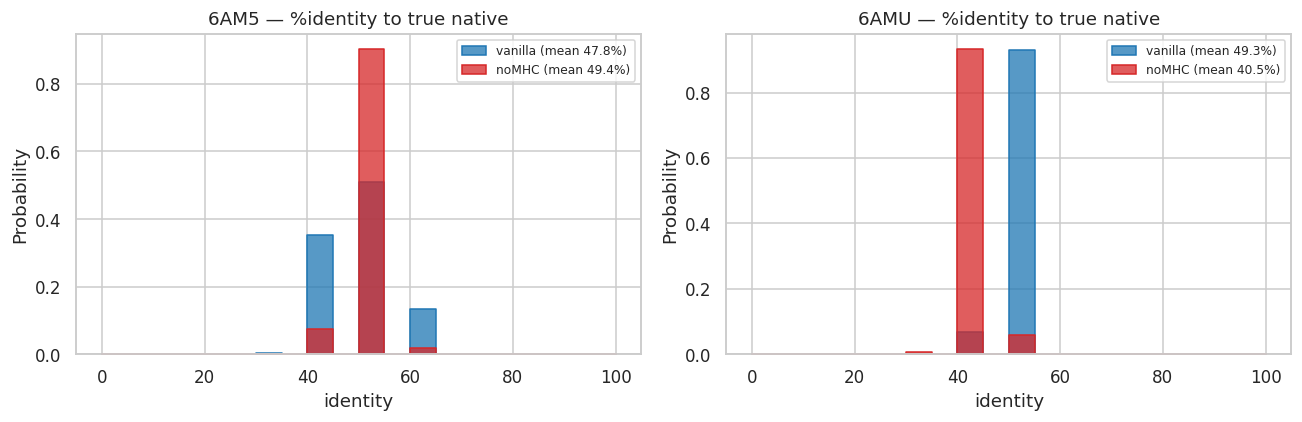

mean  median   std
backbone model                       
6AM5     noMHC    49.42    50.0  3.09
         vanilla  47.77    50.0  6.72
6AMU     noMHC    40.50    40.0  2.54
         vanilla  49.30    50.0  2.55

In [5]:
def perpos_recovery(seqs, ref):
    P = np.array([list(s) for s in seqs])
    return (P == np.array(list(ref))).mean(0) * 100

rows = []
for pid in ["6AM5","6AMU"]:
    for m in ["vanilla","noMHC"]:
        seqs = nat[(nat.backbone==pid)&(nat.model==m)].peptide.values
        if len(seqs)==0: continue
        rec = perpos_recovery(seqs, NAT[pid])
        rows.append({"crystal":pid,"model":m,**{f"P{i+1}":rec[i] for i in range(L)}})
perpos_df = pd.DataFrame(rows)
display(perpos_df.round(1))

fig, ax = plt.subplots(1, 2, figsize=(12,4))
for i, pid in enumerate(["6AM5","6AMU"]):
    for m in ["vanilla","noMHC"]:
        s = nat[(nat.backbone==pid)&(nat.model==m)].identity
        if len(s): sns.histplot(s, bins=np.arange(0,101,5), ax=ax[i], color=MODEL_COLOR[m],
                                 label=f"{m} (mean {s.mean():.1f}%)", element="step", stat="probability")
    ax[i].set_title(f"{pid} — %identity to true native"); ax[i].legend(fontsize=8)
plt.tight_layout(); plt.savefig(FIGDIR/"native_identity_distributions.png", bbox_inches="tight"); plt.show()
nat.groupby(["backbone","model"]).identity.agg(["mean","median","std"]).round(2)

## 4. Consensus sequences

In [6]:
cons_rows = []
for pid in ["6AM5","6AMU"]:
    for m in ["vanilla","noMHC"]:
        seqs = nat[(nat.backbone==pid)&(nat.model==m)].peptide.values
        c = consensus_seq(seqs)
        ham = sum(a!=b for a,b in zip(c, NAT[pid])) if c else None
        cons_rows.append({"backbone":pid,"model":m,"consensus":c,"native":NAT[pid],"hamming_to_native":ham})
cons_df = pd.DataFrame(cons_rows)
display(cons_df)

,backbone,model,consensus,native,hamming_to_native
0,6AM5,vanilla,MTLGTGVLPV,SMLGIGIVPV,5
1,6AM5,noMHC,MLPGIGILPF,SMLGIGIVPV,5
2,6AMU,vanilla,MLPDLGLGFD,MMWDRGLGMM,5
3,6AMU,noMHC,MLPDMGEGFG,MMWDRGLGMM,6


## 5. Amino-acid composition & distribution shift (Δ = vanilla − noMHC)

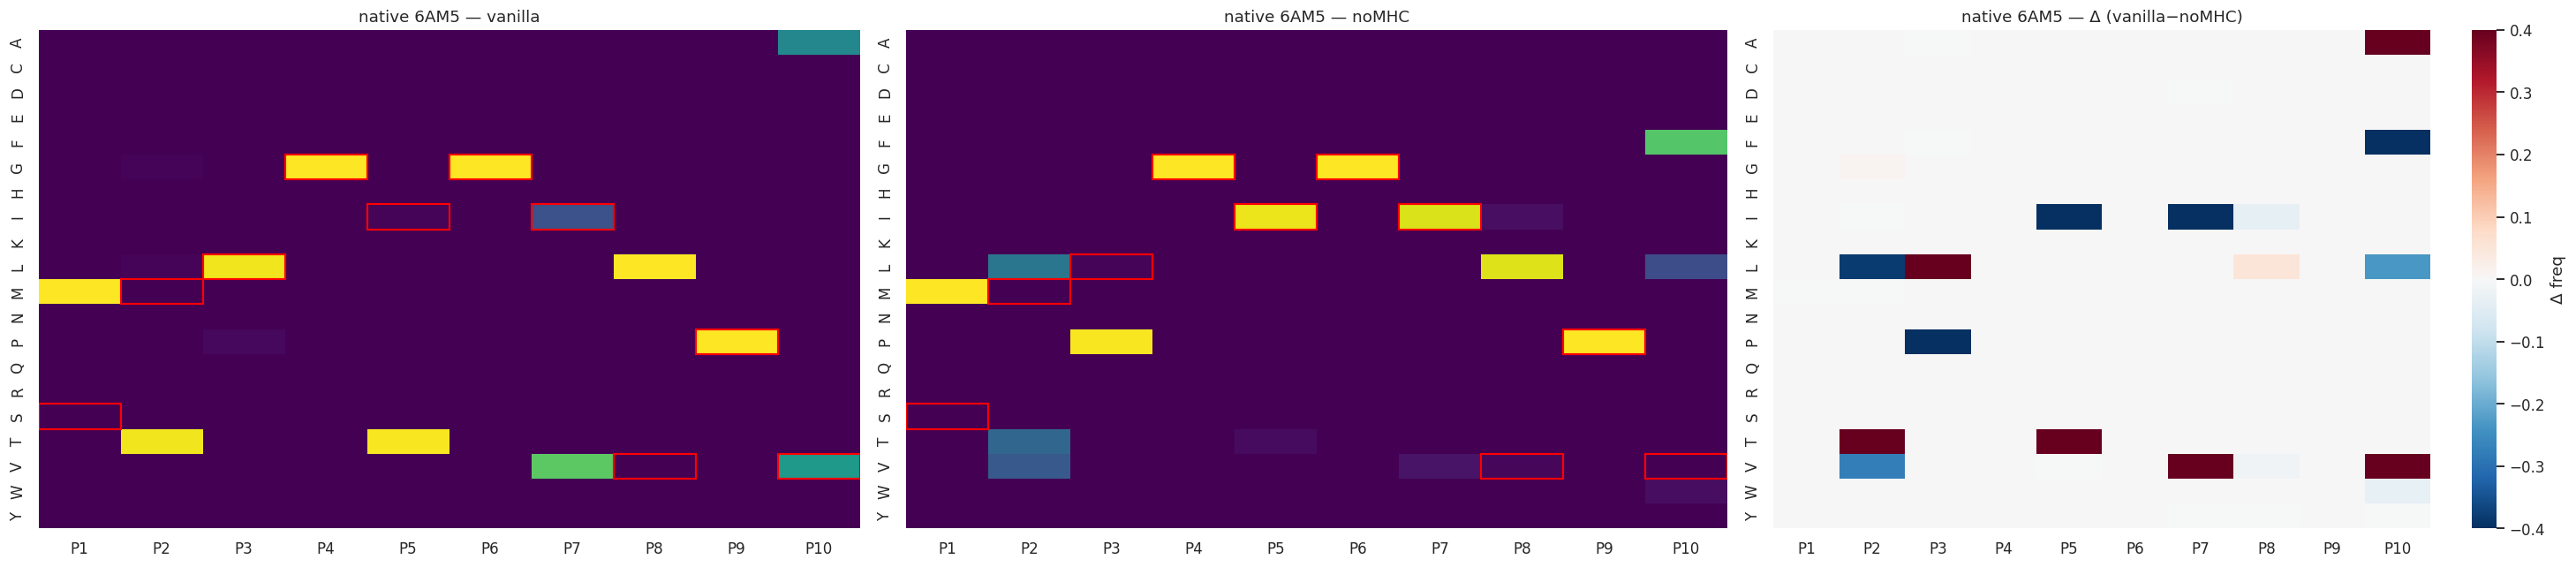

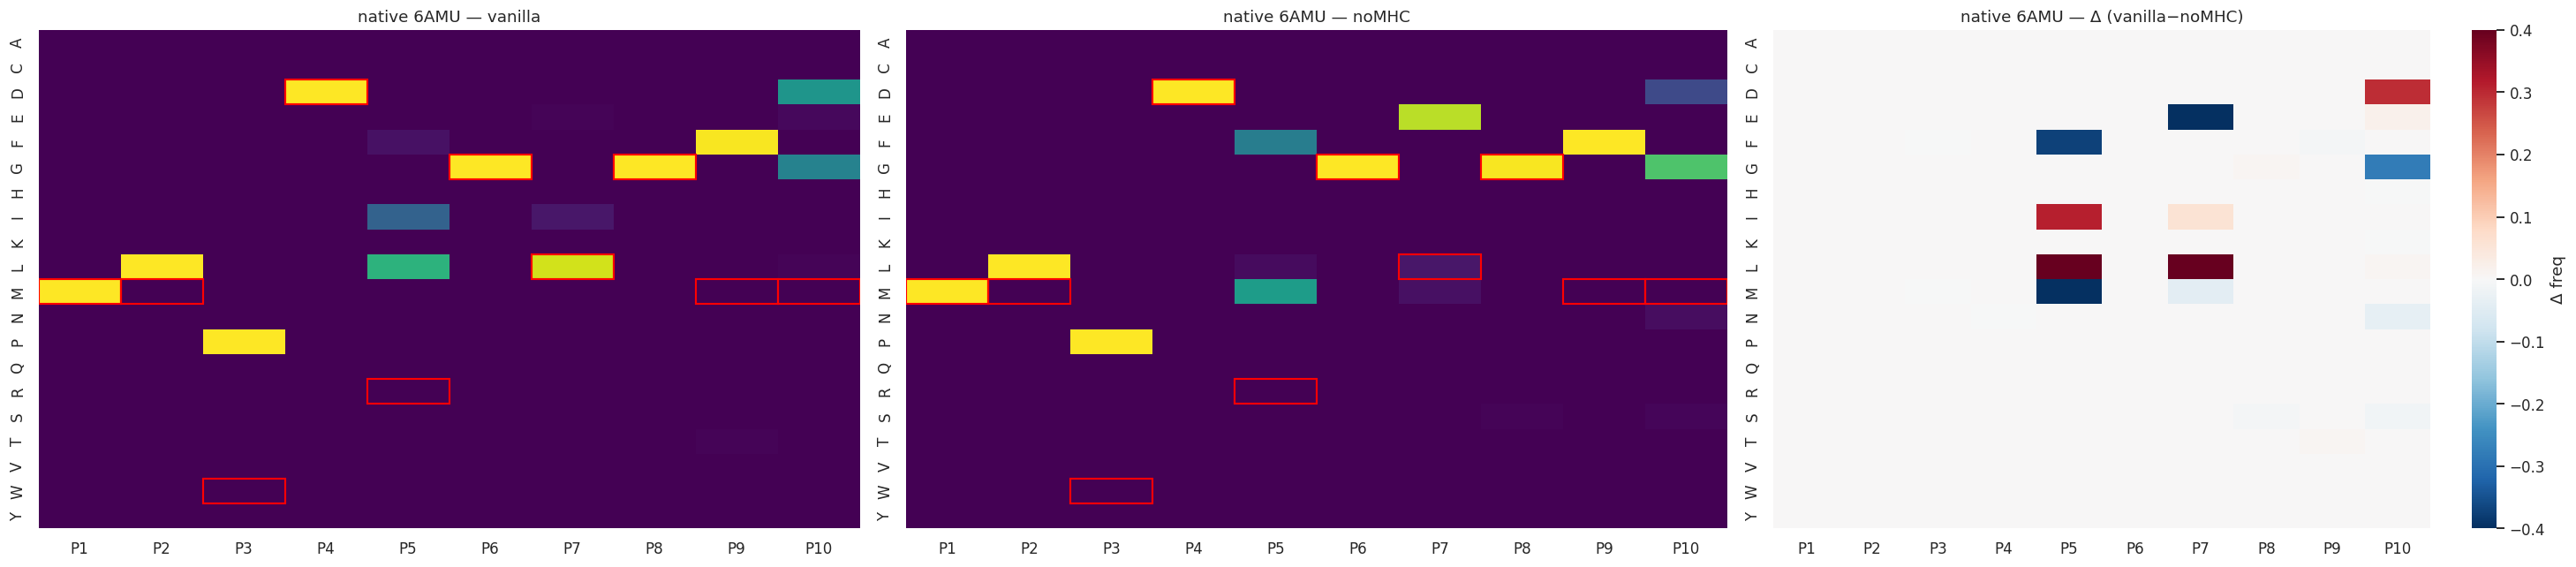

In [7]:
for pid in ["6AM5","6AMU"]:
    fV = freq_matrix(nat[(nat.backbone==pid)&(nat.model=="vanilla")].peptide.values)
    fN = freq_matrix(nat[(nat.backbone==pid)&(nat.model=="noMHC")].peptide.values)
    fig, ax = plt.subplots(1,3, figsize=(2.1*L+6,6))
    for a,(M,t) in zip(ax[:2], [(fV,"vanilla"),(fN,"noMHC")]):
        sns.heatmap(M.T, cmap="viridis", vmin=0, vmax=1, ax=a, cbar=False,
                    xticklabels=[f"P{i+1}" for i in range(L)], yticklabels=AA)
        for i,c in enumerate(NAT[pid]):
            if c in AA_IDX: a.add_patch(plt.Rectangle((i,AA_IDX[c]),1,1,fill=False,ec="red",lw=1.4))
        a.set_title(f"native {pid} — {t}")
    sns.heatmap((fV-fN).T, cmap="RdBu_r", center=0, vmin=-0.4, vmax=0.4, ax=ax[2],
                xticklabels=[f"P{i+1}" for i in range(L)], yticklabels=AA, cbar_kws={"label":"Δ freq"})
    ax[2].set_title(f"native {pid} — Δ (vanilla−noMHC)")
    plt.tight_layout(); plt.savefig(FIGDIR/f"aa_freq_delta_native_{pid}.png", bbox_inches="tight"); plt.show()

## 6. Pairwise similarity — within-model vs across-model identity

In [8]:
def pairwise_identity_sample(seqs, n=250, rng=np.random.default_rng(0)):
    seqs = np.array(seqs)
    if len(seqs) > n: seqs = rng.choice(seqs, n, replace=False)
    P = np.array([list(s) for s in seqs])
    M = (P[:,None,:] == P[None,:,:]).mean(2)*100
    iu = np.triu_indices(len(seqs), k=1)
    return M[iu]

sim_rows = []
for m in ["vanilla","noMHC"]:
    seqs = nat[nat.model==m].peptide.values
    within = pairwise_identity_sample(seqs)
    sim_rows.append({"model":m,"comparison":"within-model","mean_identity":within.mean(),"std":within.std()})
v = nat[nat.model=="vanilla"].peptide.values; n_ = nat[nat.model=="noMHC"].peptide.values
rng = np.random.default_rng(0)
vv = rng.choice(v, 250, replace=False); nn = rng.choice(n_, 250, replace=False)
Pv = np.array([list(s) for s in vv]); Pn = np.array([list(s) for s in nn])
cross = (Pv[:,None,:]==Pn[None,:,:]).mean(2)*100
sim_rows.append({"model":"vanilla-vs-noMHC","comparison":"across-model","mean_identity":cross.mean(),"std":cross.std()})
sim_df = pd.DataFrame(sim_rows)
display(sim_df.round(2))

,model,comparison,mean_identity,std
0,vanilla,within-model,55.19,35.09
1,noMHC,within-model,60.61,27.98
2,vanilla-vs-noMHC,across-model,47.96,21.81


## 7. PCA of one-hot encoded sequences

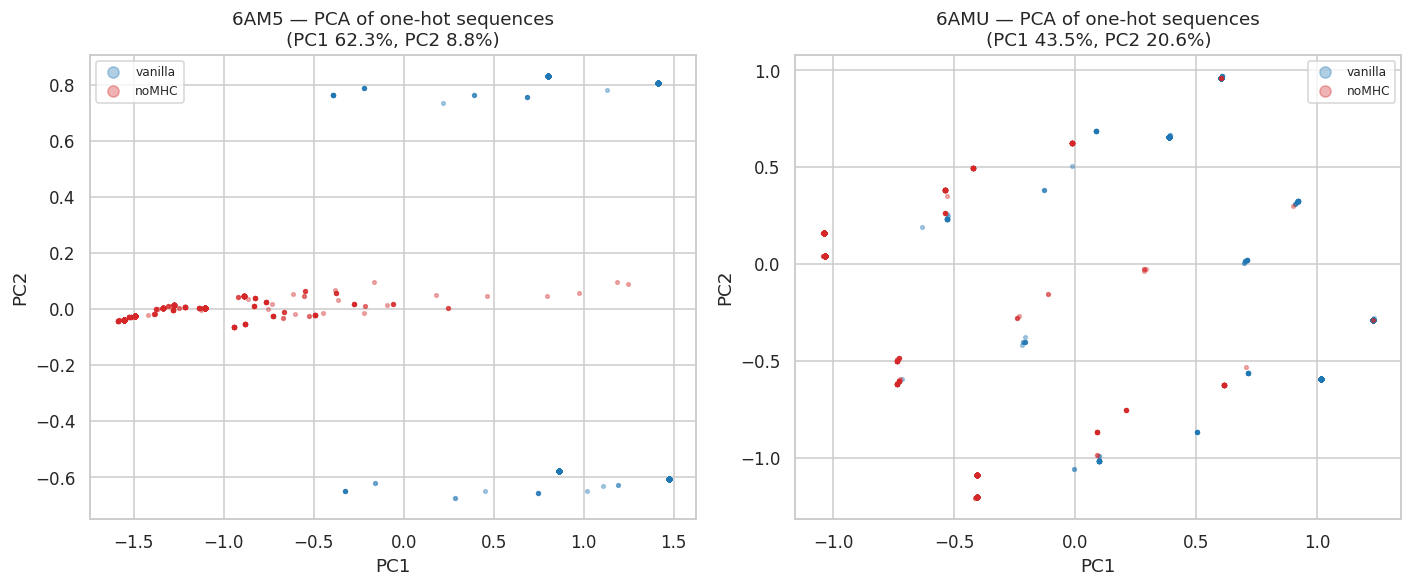

In [9]:
def onehot(seqs):
    P = np.zeros((len(seqs), L*len(AA)))
    for r,s in enumerate(seqs):
        for i,c in enumerate(s):
            if c in AA_IDX: P[r, i*len(AA)+AA_IDX[c]] = 1
    return P

fig, axes = plt.subplots(1, 2, figsize=(13,5.5))
for ax, pid in zip(axes, ["6AM5","6AMU"]):
    sub = nat[nat.backbone==pid]
    samp = pd.concat([g.sample(min(1500,len(g)), random_state=0) for _, g in sub.groupby("model")],
                      ignore_index=True)
    X = onehot(samp.peptide.values)
    pca = PCA(n_components=2, random_state=0)
    Z = pca.fit_transform(X)
    for m in ["vanilla","noMHC"]:
        mask = (samp.model==m).values
        ax.scatter(Z[mask,0], Z[mask,1], s=6, alpha=.35, color=MODEL_COLOR[m], label=m)
    ax.set_title(f"{pid} — PCA of one-hot sequences\n(PC1 {pca.explained_variance_ratio_[0]*100:.1f}%, "
                 f"PC2 {pca.explained_variance_ratio_[1]*100:.1f}%)")
    ax.set_xlabel("PC1"); ax.set_ylabel("PC2"); ax.legend(fontsize=8, markerscale=3)
plt.tight_layout(); plt.savefig(FIGDIR/"pca_native.png", bbox_inches="tight"); plt.show()

## 8. Per-sequence scores

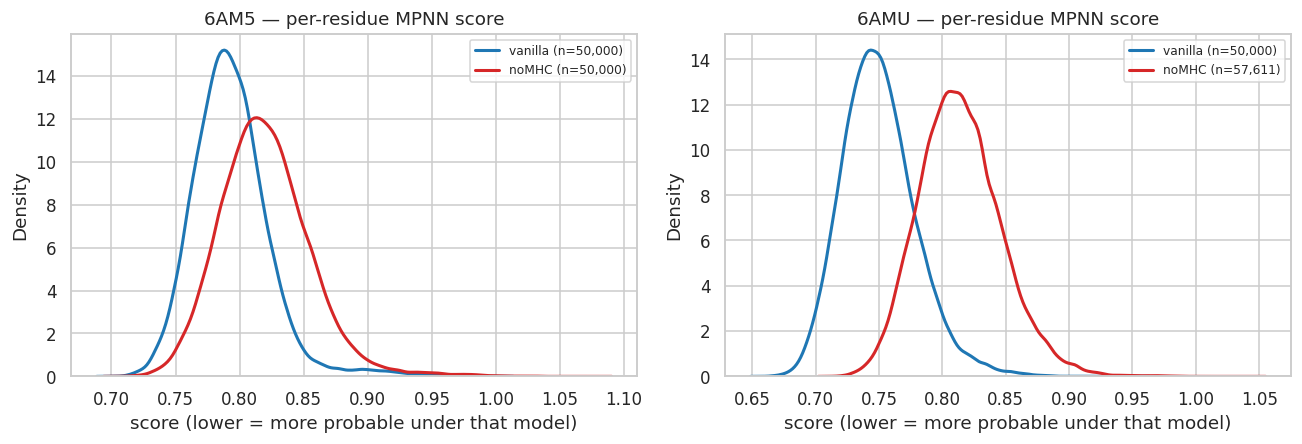

mean  median     std
backbone model                          
6AM5     noMHC    0.8198  0.8175  0.0353
         vanilla  0.7932  0.7909  0.0301
6AMU     noMHC    0.8141  0.8123  0.0324
         vanilla  0.7501  0.7479  0.0291

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12,4.2))
for ax, pid in zip(axes, ["6AM5","6AMU"]):
    for m in ["vanilla","noMHC"]:
        s = nat[(nat.backbone==pid)&(nat.model==m)].score.dropna()
        if len(s): sns.kdeplot(s, ax=ax, color=MODEL_COLOR[m], label=f"{m} (n={len(s):,})", lw=2)
    ax.set_title(f"{pid} — per-residue MPNN score"); ax.set_xlabel("score (lower = more probable under that model)")
    ax.legend(fontsize=8)
plt.tight_layout(); plt.savefig(FIGDIR/"score_distributions_native.png", bbox_inches="tight"); plt.show()
nat.groupby(["backbone","model"]).score.agg(["mean","median","std"]).round(4)

## 9. De-novo designs on noMHC weights

The 5 closest-to-crossing de-novo designs (`outputs/mpnn_nomhc_topcross_50k/seqs/rfd_*.fa`), each
~50k noMHC-generated sequences. **No vanilla counterpart at this depth exists for these backbones** —
this is a pure noMHC corpus, analyzed on its own terms and against the two native registers (also
noMHC, for a same-model comparison isolating backbone identity as the only variable).

In [11]:
DENOVO = {
    "rfd_k18_44": "outputs/mpnn_nomhc_topcross_50k/seqs/rfd_k18_44.fa",
    "rfd_L4_4992623": "outputs/mpnn_nomhc_topcross_50k/seqs/rfd_L4_4992623.fa",
    "rfd_k18_12": "outputs/mpnn_nomhc_topcross_50k/seqs/rfd_k18_12.fa",
    "rfd_k18_109": "outputs/mpnn_nomhc_topcross_50k/seqs/rfd_k18_109.fa",
    "rfd_L1_0082638": "outputs/mpnn_nomhc_topcross_50k/seqs/rfd_L1_0082638.fa",
}
denovo_seqs = {}
for name, relpath in DENOVO.items():
    d, _ = load_fasta_split(ROOT/relpath)
    denovo_seqs[name] = d.peptide.values
    status = "COMPLETE" if len(d) >= 50000 else f"IN PROGRESS ({len(d):,}/50,000)"
    print(f"{name}: {len(d):,} sequences -- {status}")

# same-model (noMHC) native reference populations, for a same-model backbone-only comparison
denovo_seqs["native_GIG_6AM5"] = nat[(nat.backbone=="6AM5")&(nat.model=="noMHC")].peptide.values
denovo_seqs["native_DRG_6AMU"] = nat[(nat.backbone=="6AMU")&(nat.model=="noMHC")].peptide.values

POPS = ["native_GIG_6AM5","native_DRG_6AMU"] + list(DENOVO.keys())
print(f"\n{sum(len(v) for v in denovo_seqs.values()):,} total sequences across {len(POPS)} populations")

rfd_k18_44: 50,000 sequences -- COMPLETE
rfd_L4_4992623: 50,000 sequences -- COMPLETE


rfd_k18_12: 50,000 sequences -- COMPLETE
rfd_k18_109: 50,000 sequences -- COMPLETE
rfd_L1_0082638: 1,231 sequences -- IN PROGRESS (1,231/50,000)



308,842 total sequences across 7 populations


### Jensen-Shannon divergence — pooled AA composition, all 7 populations

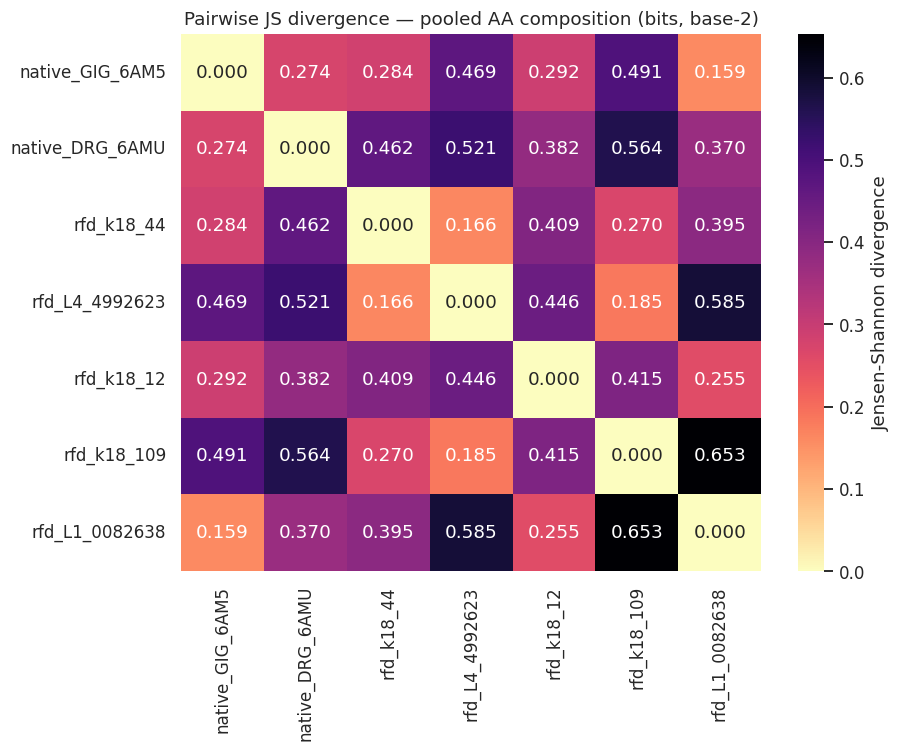

Closest de-novo design to each native register (by JS divergence):
  native_GIG_6AM5: rfd_L1_0082638=0.159, rfd_k18_44=0.284, rfd_k18_12=0.292, rfd_L4_4992623=0.469, rfd_k18_109=0.491
  native_DRG_6AMU: rfd_L1_0082638=0.370, rfd_k18_12=0.382, rfd_k18_44=0.462, rfd_L4_4992623=0.521, rfd_k18_109=0.564


In [12]:
def pooled_aa_dist(seqs):
    c = Counter()
    for s in seqs:
        c.update(s)
    v = np.array([c.get(a,0) for a in AA], dtype=float)
    return v / v.sum()

dists = {p: pooled_aa_dist(denovo_seqs[p]) for p in POPS if len(denovo_seqs[p]) > 0}
valid_pops = list(dists.keys())
JS = np.zeros((len(valid_pops), len(valid_pops)))
for i, p1 in enumerate(valid_pops):
    for j, p2 in enumerate(valid_pops):
        JS[i,j] = jensenshannon(dists[p1], dists[p2], base=2)**2   # squared JS distance = JS divergence

js_df = pd.DataFrame(JS, index=valid_pops, columns=valid_pops)
fig, ax = plt.subplots(figsize=(8.5,7))
sns.heatmap(js_df, annot=True, fmt=".3f", cmap="magma_r", ax=ax, cbar_kws={"label":"Jensen-Shannon divergence"})
ax.set_title("Pairwise JS divergence — pooled AA composition (bits, base-2)")
plt.tight_layout(); plt.savefig(FIGDIR/"js_divergence_denovo.png", bbox_inches="tight"); plt.show()

print("Closest de-novo design to each native register (by JS divergence):")
for ref in ["native_GIG_6AM5","native_DRG_6AMU"]:
    if ref not in js_df.index: continue
    ranked = js_df[ref].drop(index=[p for p in ["native_GIG_6AM5","native_DRG_6AMU"] if p in js_df.index]).sort_values()
    print(f"  {ref}: " + ", ".join(f"{k}={v:.3f}" for k,v in ranked.items()))

### Sequence logos — 5 de-novo designs + 2 natives, multi-panel

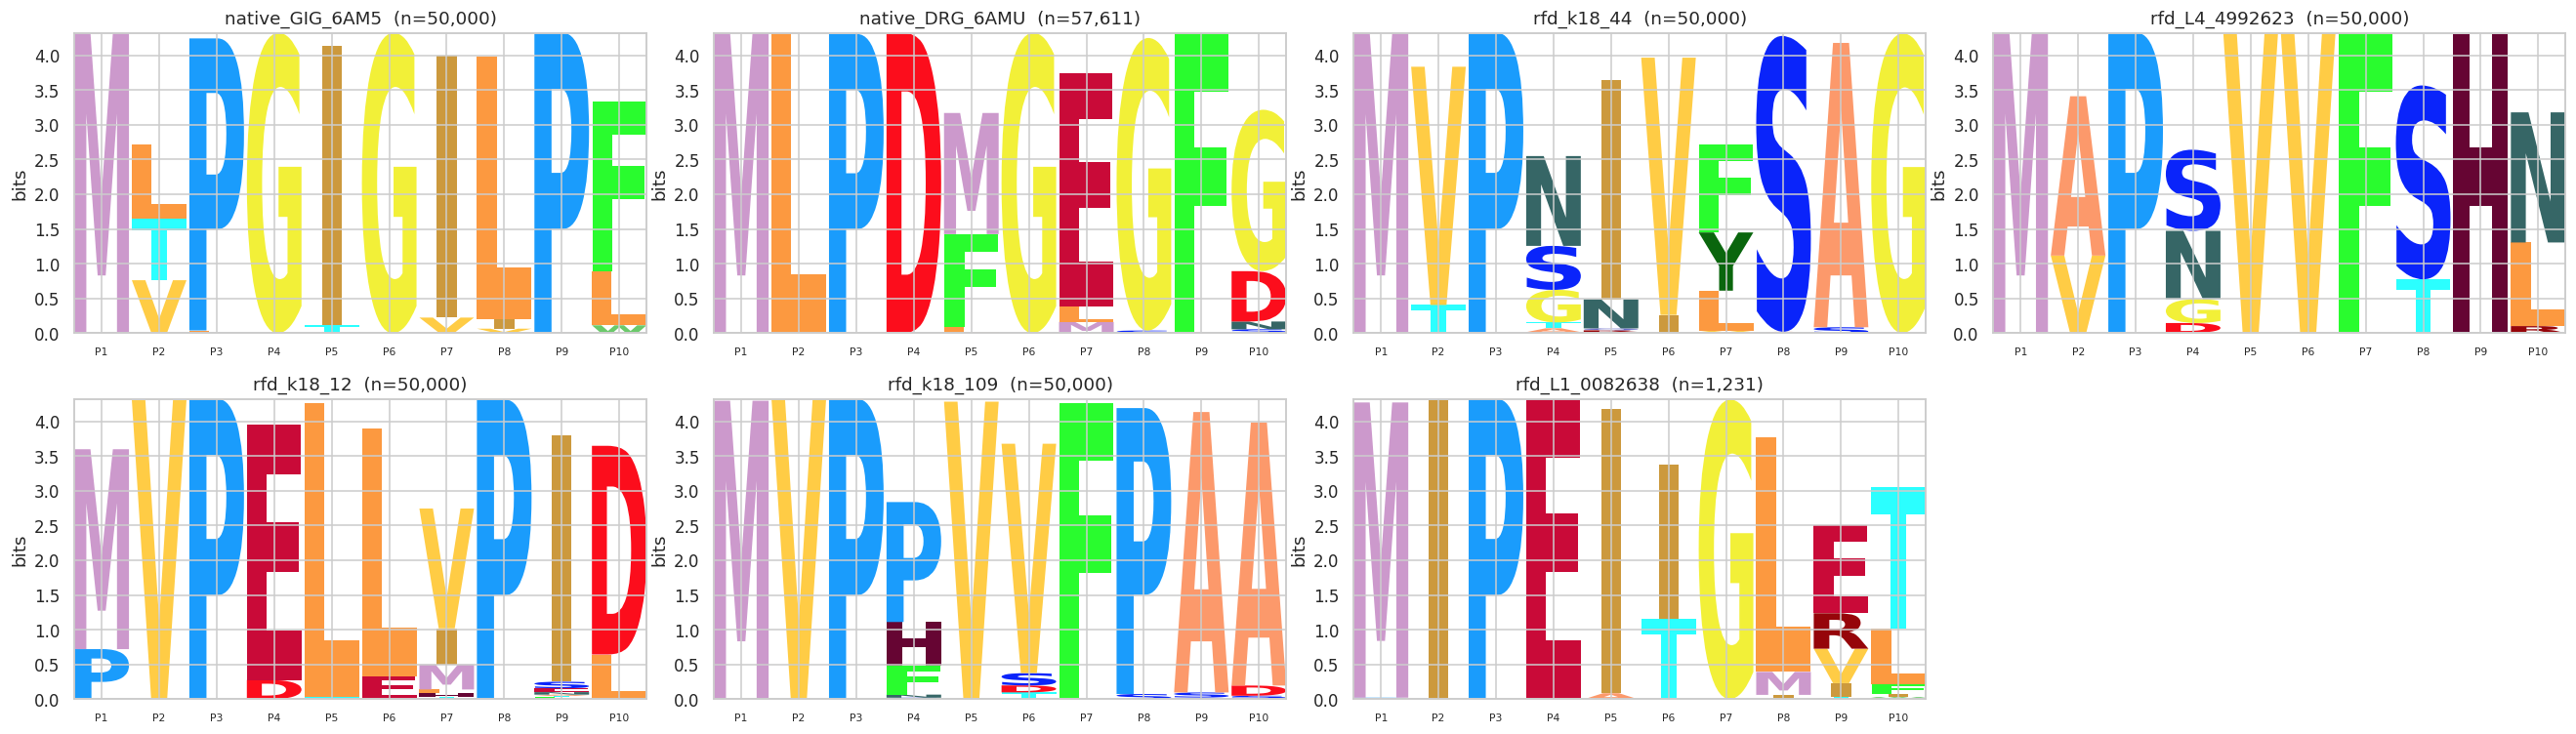

In [13]:
fig, axes = plt.subplots(2, 4, figsize=(24, 7))
axes = axes.flatten()
panel_order = ["native_GIG_6AM5","native_DRG_6AMU"] + list(DENOVO.keys())
for ax, name in zip(axes, panel_order):
    plot_logo(ax, denovo_seqs.get(name, []), name)
for ax in axes[len(panel_order):]:
    ax.set_axis_off()
plt.tight_layout(); plt.savefig(FIGDIR/"sequence_logos_denovo.png", bbox_inches="tight"); plt.show()

## 10. Summary & artifacts

In [14]:
summary = {
    "native_noMHC_6AMU_n": int(len(nat[(nat.backbone=='6AMU')&(nat.model=='noMHC')])),
    "denovo_status": {k: int(len(v)) for k,v in denovo_seqs.items() if k in DENOVO},
    "js_divergence_matrix": js_df.round(4).to_dict(),
}
import json; print(json.dumps(summary, indent=2))

nat.to_csv(ROOT/"outputs/analysis/nomhc_vs_vanilla_full_native_sequences.csv", index=False)
stats.to_csv(ROOT/"outputs/analysis/nomhc_vs_vanilla_full_basicstats.csv", index=False)
js_df.to_csv(ROOT/"outputs/analysis/nomhc_denovo_js_divergence.csv")
pd.Series(summary).to_json(ROOT/"outputs/analysis/nomhc_vs_vanilla_full_summary.json")
print("\nsaved outputs/analysis/nomhc_vs_vanilla_full_{native_sequences,basicstats}.csv, "
      "nomhc_denovo_js_divergence.csv + summary.json")

{
  "native_noMHC_6AMU_n": 57611,
  "denovo_status": {
    "rfd_k18_44": 50000,
    "rfd_L4_4992623": 50000,
    "rfd_k18_12": 50000,
    "rfd_k18_109": 50000,
    "rfd_L1_0082638": 1231
  },
  "js_divergence_matrix": {
    "native_GIG_6AM5": {
      "native_GIG_6AM5": 0.0,
      "native_DRG_6AMU": 0.2742,
      "rfd_k18_44": 0.2836,
      "rfd_L4_4992623": 0.4693,
      "rfd_k18_12": 0.2919,
      "rfd_k18_109": 0.4906,
      "rfd_L1_0082638": 0.1595
    },
    "native_DRG_6AMU": {
      "native_GIG_6AM5": 0.2742,
      "native_DRG_6AMU": 0.0,
      "rfd_k18_44": 0.462,
      "rfd_L4_4992623": 0.5209,
      "rfd_k18_12": 0.3817,
      "rfd_k18_109": 0.5637,
      "rfd_L1_0082638": 0.37
    },
    "rfd_k18_44": {
      "native_GIG_6AM5": 0.2836,
      "native_DRG_6AMU": 0.462,
      "rfd_k18_44": 0.0,
      "rfd_L4_4992623": 0.1655,
      "rfd_k18_12": 0.4085,
      "rfd_k18_109": 0.2703,
      "rfd_L1_0082638": 0.3952
    },
    "rfd_L4_4992623": {
      "native_GIG_6AM5": 0.4693,
   


saved outputs/analysis/nomhc_vs_vanilla_full_{native_sequences,basicstats}.csv, nomhc_denovo_js_divergence.csv + summary.json


---
## Appendix — Ladder & Grind (sequence logos only)

Both campaigns have vanilla+noMHC coverage on identical backbones, but at mismatched temperature
(vanilla T=0.1, noMHC T=0.3) and low per-backbone N (ladder ~2000/49 vanilla, grind ~49 vanilla) —
not enough statistical power for recovery/PCA/similarity to say anything reliable (see the previous
version of this notebook). Logos only, pooled across all backbones in each campaign, no other
analysis.

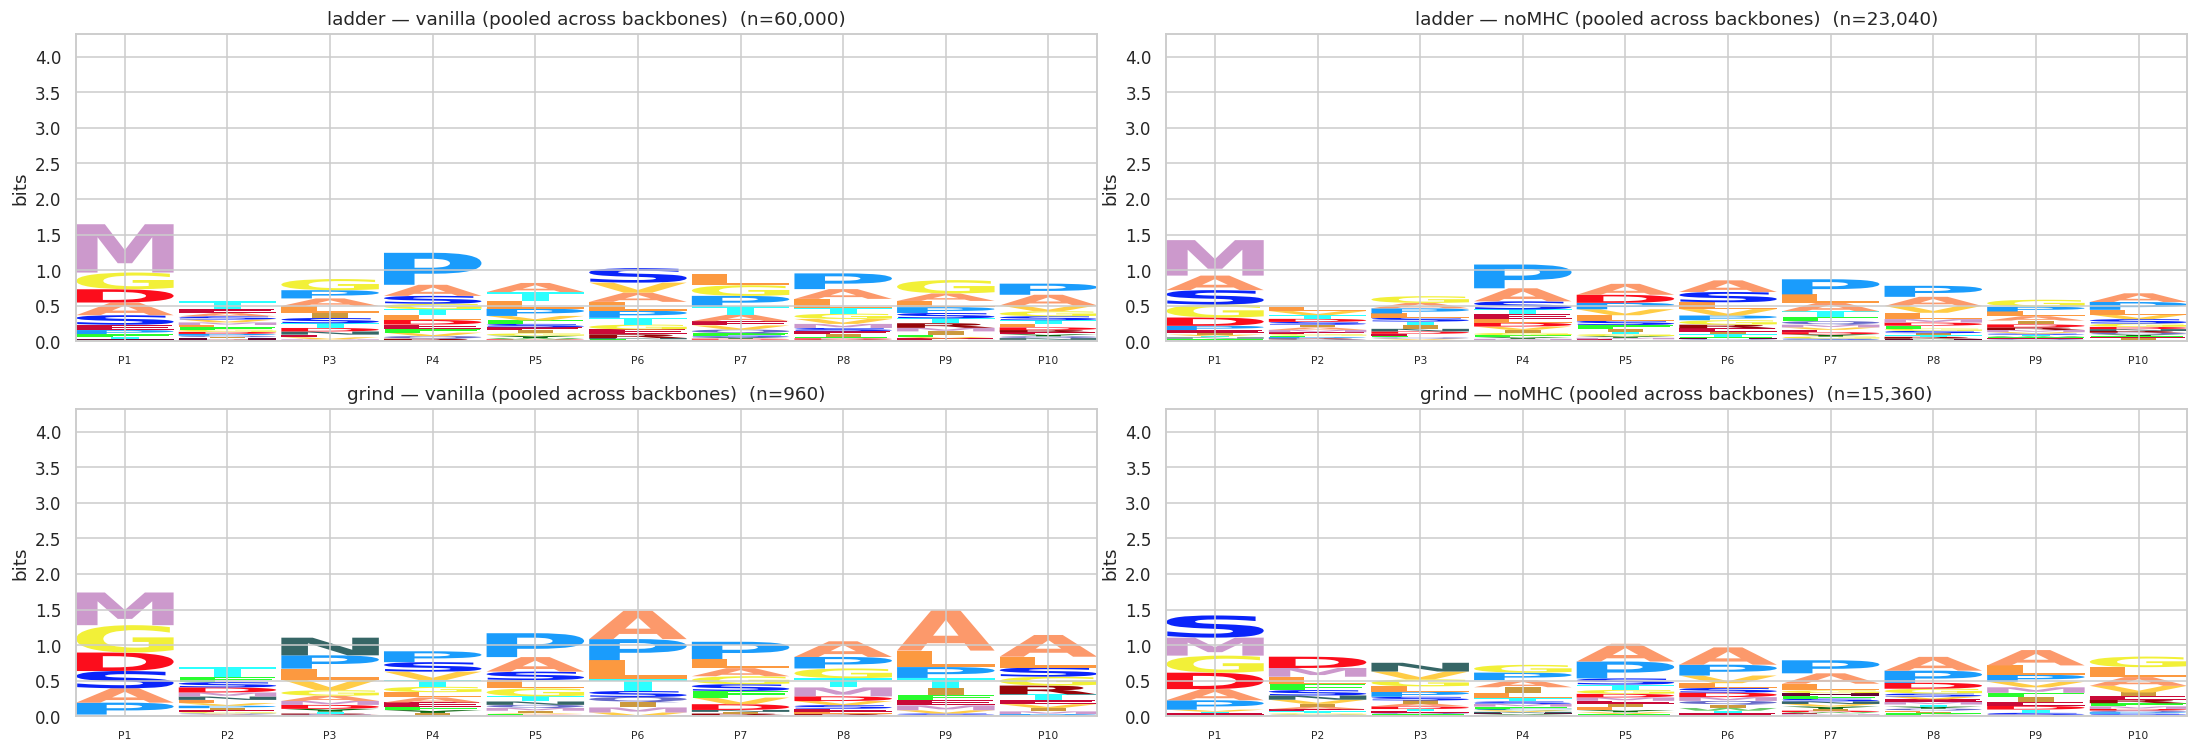

In [15]:
manifest = pd.read_csv(ROOT/"outputs/mpnn_nomhc_allbb/manifest.csv")
manifest["src"] = manifest["src"].str.strip()
ladder_grind_seqs = {}
for campaign in ["ladder", "grind"]:
    sub = manifest[manifest.src.str.contains(f"outputs/{campaign}/pdb", na=False)]
    for model, base in [("vanilla", None), ("noMHC", ROOT/"outputs/mpnn_nomhc_allbb_deep2/seqs")]:
        pooled = []
        for _, row in sub.iterrows():
            name = Path(row.src).stem; bbid = row.target
            path = (ROOT/f"outputs/{campaign}/seqs/{name}.fa") if model=="vanilla" else (base/f"{bbid}.fa")
            d, _ = load_fasta_split(path)
            pooled.append(d.peptide.values)
        ladder_grind_seqs[(campaign, model)] = np.concatenate(pooled) if pooled else np.array([])

fig, axes = plt.subplots(2, 2, figsize=(20, 7))
for r, campaign in enumerate(["ladder","grind"]):
    for c, model in enumerate(["vanilla","noMHC"]):
        plot_logo(axes[r][c], ladder_grind_seqs[(campaign,model)], f"{campaign} — {model} (pooled across backbones)")
plt.tight_layout(); plt.savefig(FIGDIR/"sequence_logos_ladder_grind.png", bbox_inches="tight"); plt.show()